In [12]:
import sys, os, yaml
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from src.utils.GraphGradCAM import *

In [13]:
from src.datasets.gqa_graph_dataset import GQAGraphDataset
from src.models.gnn import GCNEmbeddingNet, GINEEmbeddingNet

## Caricamento modelli

In [14]:
config_path = os.path.join(BASE_DIR, "experiments", "configs", "gcn_config.yaml")
with open(config_path) as f:
    cfg_gcn = yaml.safe_load(f)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path  = os.path.join(BASE_DIR, cfg_gcn["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab_gcn = checkpoint["node_vocab"]
rel_vocab_gcn  = checkpoint["rel_vocab"]

gcn_model = GCNEmbeddingNet(
    num_node_types=len(node_vocab_gcn) + 1,
    emb_dim=cfg_gcn["model"]["emb_dim"],
    hidden_dim=cfg_gcn["model"]["hidden_dim"],
    num_layers=cfg_gcn["model"]["num_layers"],
    dropout=cfg_gcn["model"]["dropout"],
    use_bbox=cfg_gcn["model"]["use_bbox"],
    node_emb_dim=cfg_gcn["model"]["node_emb_dim"],
).to(device)
gcn_model.load_state_dict(checkpoint["model_state_dict"])
gcn_model.eval()
print(f"GCN caricato da: {ckpt_path}")

GCN caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gcn20.pth


In [15]:
config_path = os.path.join(BASE_DIR, "experiments", "configs", "gine_config.yaml")
with open(config_path) as f:
    cfg_gine = yaml.safe_load(f)

ckpt_path  = os.path.join(BASE_DIR, cfg_gine["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab_gine = checkpoint["node_vocab"]
rel_vocab_gine  = checkpoint["rel_vocab"]

gine_model = GINEEmbeddingNet(
    num_node_types=len(node_vocab_gine) + 1,
    edge_vocab_size=len(rel_vocab_gine),
    emb_dim=cfg_gine["model"]["emb_dim"],
    hidden_dim=cfg_gine["model"]["hidden_dim"],
    num_layers=cfg_gine["model"]["num_layers"],
    dropout=cfg_gine["model"]["dropout"],
    use_bbox=cfg_gine["model"]["use_bbox"],
    node_emb_dim=cfg_gine["model"]["node_emb_dim"],
).to(device)
gine_model.load_state_dict(checkpoint["model_state_dict"])
gine_model.eval()
print(f"GINE caricato da: {ckpt_path}")

GINE caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gnn20.pth


## Dataset di validazione

In [16]:
df_train = pd.read_csv(os.path.join(BASE_DIR, cfg_gcn["data"]["train_csv"]))
df_val   = pd.read_csv(os.path.join(BASE_DIR, cfg_gcn["data"]["val_csv"]))

all_labels = df_train["labels"].unique()
label2idx  = {l: i for i, l in enumerate(all_labels)}
idx2label  = {i: l for l, i in label2idx.items()}

df_train["labels"] = df_train["labels"].map(label2idx)
df_val["labels"]   = df_val["labels"].map(label2idx)

val_dataset_gcn = GQAGraphDataset(
    df=df_val, label_col="labels",
    node_vocab=node_vocab_gcn, rel_vocab=rel_vocab_gcn,
    label2idx=label2idx, idx2label=idx2label,
    use_bbox=cfg_gcn["model"]["use_bbox"],
)
val_dataset_gine = GQAGraphDataset(
    df=df_val, label_col="labels",
    node_vocab=node_vocab_gine, rel_vocab=rel_vocab_gine,
    label2idx=label2idx, idx2label=idx2label,
    use_bbox=cfg_gine["model"]["use_bbox"],
)

IMAGE_DIR = os.path.join(BASE_DIR, "data", "images")
print(f"Val dataset size: {len(val_dataset_gcn)}")

Val dataset size: 3208


In [17]:
# 1. Istanzia il dataset di training (assicurati che usi lo stesso vocabolario)
train_dataset_gcn = GQAGraphDataset(
    df=df_train, label_col="labels",
    node_vocab=node_vocab_gcn, rel_vocab=rel_vocab_gcn,
    label2idx=label2idx, idx2label=idx2label,
    use_bbox=cfg_gcn["model"]["use_bbox"],
)

train_dataset_gine = GQAGraphDataset(
    df=df_train, label_col="labels",
    node_vocab=node_vocab_gine, rel_vocab=rel_vocab_gine,
    label2idx=label2idx, idx2label=idx2label,
    use_bbox=cfg_gine["model"]["use_bbox"],
)

print(f"Train dataset size: {len(train_dataset_gcn)}")

# 2. Estrai gli embedding SOLO dal training set per costruire i prototipi
print("Building GCN training embeddings for prototypes...")
train_embs_gcn = build_gallery_embeddings(gcn_model, train_dataset_gcn, device, model_type="gcn")

print("Building GINE training embeddings for prototypes...")
train_embs_gine = build_gallery_embeddings(gine_model, train_dataset_gine, device, model_type="gine")

# 3. Calcola i prototipi stabili usando le label del training set
prototypes_gcn  = compute_class_prototypes(train_embs_gcn, df_train["labels"].values)
prototypes_gine = compute_class_prototypes(train_embs_gine, df_train["labels"].values)

print("Prototipi calcolati correttamente dal TRAINING SET.")

Train dataset size: 22482
Building GCN training embeddings for prototypes...
Building GINE training embeddings for prototypes...
Prototipi calcolati correttamente dal TRAINING SET.


## 1 · GraphGrad-CAM — Node Importance Aggregata per Classe

Aggreghiamo l'importanza Grad-CAM su **N campioni per classe** e mediamo per tipo di nodo.

Questo risponde alla domanda corretta:
> *"Per riconoscere oggetti della classe X, su quali tipi di nodo si concentra il modello in media?"*

L'aggregazione per tipo di nodo è necessaria perché grafi diversi hanno strutture
diverse: mediare per indice sarebbe scorretto.

In [18]:
print(label2idx)
print(idx2label)

{'a person playing a sport': 0, 'a street scene in a city': 1, 'a living room interior': 2, 'a wild animal in nature': 3, 'a food scene': 4, 'a beach scene': 5, 'a bedroom interior': 6, 'a bathroom interior': 7, 'a railway scene': 8, 'an airplane flying in the sky': 9, 'a restaurant dining scene': 10, 'a building exterior': 11, 'a kitchen interior': 12, 'a countryside landscape': 13}
{0: 'a person playing a sport', 1: 'a street scene in a city', 2: 'a living room interior', 3: 'a wild animal in nature', 4: 'a food scene', 5: 'a beach scene', 6: 'a bedroom interior', 7: 'a bathroom interior', 8: 'a railway scene', 9: 'an airplane flying in the sky', 10: 'a restaurant dining scene', 11: 'a building exterior', 12: 'a kitchen interior', 13: 'a countryside landscape'}


In [19]:
TARGET_CLASSES        = [6, 5, 4]   
NUM_SAMPLES_PER_CLASS = 100           


In [20]:

with GraphGradCAM(gcn_model,  gcn_model.convs[-1])  as cam_gcn, \
     GraphGradCAM(gine_model, gine_model.convs[-1]) as cam_gine:

    results_gcn = aggregate_node_importance_by_class(
        cam=cam_gcn,
        dataset=val_dataset_gcn,
        node_vocab=node_vocab_gcn,
        df=df_val,
        target_classes=TARGET_CLASSES,
        prototypes=prototypes_gcn, # <--- Nuovo parametro
        device=device,
        num_samples_per_class=NUM_SAMPLES_PER_CLASS,
        use_edge_attr=False,   
    )

    results_gine = aggregate_node_importance_by_class(
        cam=cam_gine,
        dataset=val_dataset_gine,
        node_vocab=node_vocab_gine,
        df=df_val,
        target_classes=TARGET_CLASSES,
        prototypes=prototypes_gine, # <--- Nuovo parametro
        device=device,
        num_samples_per_class=NUM_SAMPLES_PER_CLASS,
        use_edge_attr=True,    
    )

print("Hook rimossi e mappe basate su prototipi calcolate.")

p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
p:\Anaconda\envs\torch_new\Lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
p:\Uni\mujoco\dl26-projects\src\utils\GraphGradCAM.py:97: RuntimeWarning: Gradienti nulli per questo sample: importanza posta a zero.
  warnings.warn("Gradienti nulli per questo sample: importanza posta a zero.", RuntimeWarning)


Hook rimossi e mappe basate su prototipi calcolate.


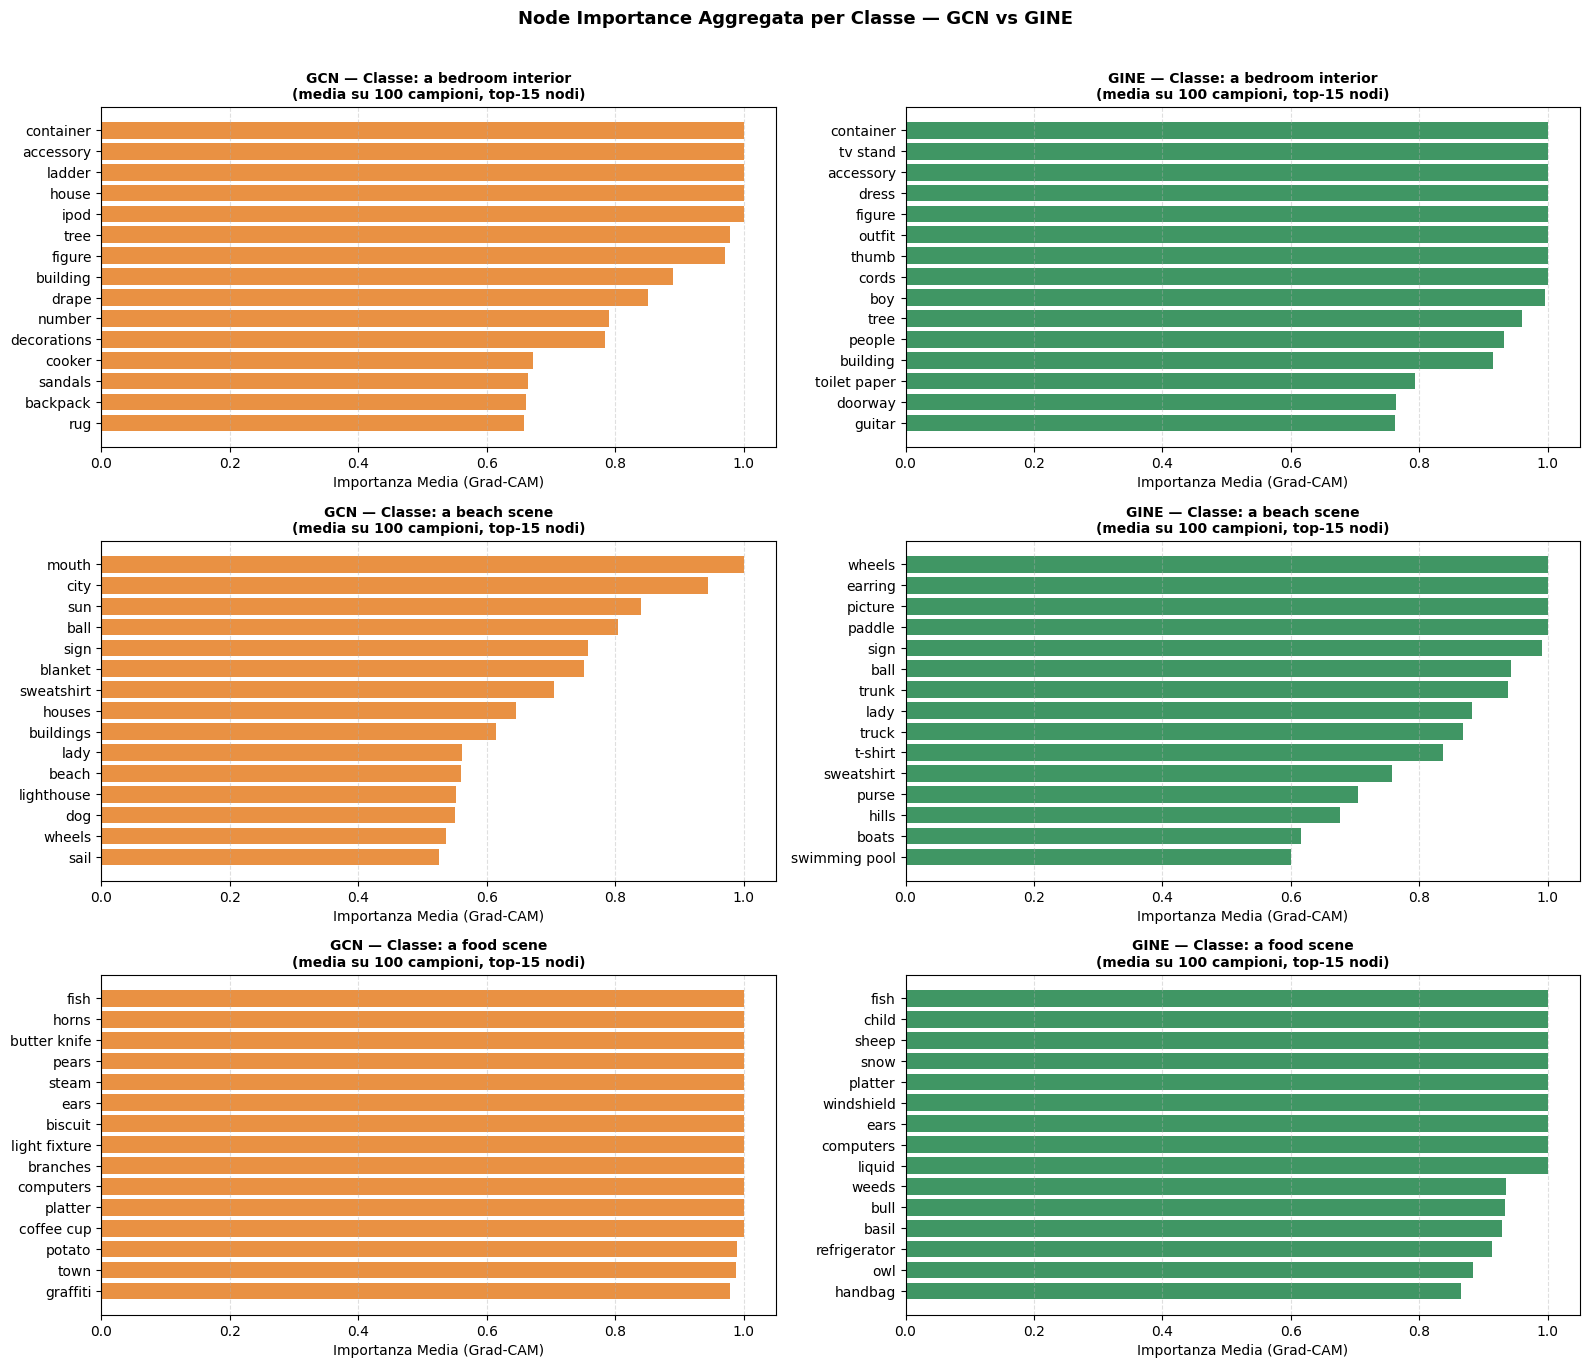

In [21]:
plot_node_importance_by_class(
    results_gcn=results_gcn,
    results_gine=results_gine,
    idx2label=idx2label,
    num_samples_per_class=NUM_SAMPLES_PER_CLASS,
    topk=15,
)

## 2 · Studio Globale Archi — GINE (GNNExplainer)

GNNExplainer ottimizza una edge mask per ogni sample e spiega quale sottoinsieme
di archi è sufficiente a riprodurre l'output. Aggregando su più campioni otteniamo
una stima dell'importanza media per tipo di relazione.

Analisi archi (GINE — GNNExplainer) su 100 campioni...


p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


           Relazione  Importanza Media  Conteggio
7        in front of          0.347765         36
8                 in          0.329025         90
9               with          0.328672         24
10                on          0.320373        208
11             above          0.310176         34
12           holding          0.308739         32
13           wearing          0.307728        150
14              near          0.304194         90
15        sitting on          0.295523         18
16         on top of          0.294374         48
17  standing next to          0.290023          6
20    to the left of          0.285236       4656


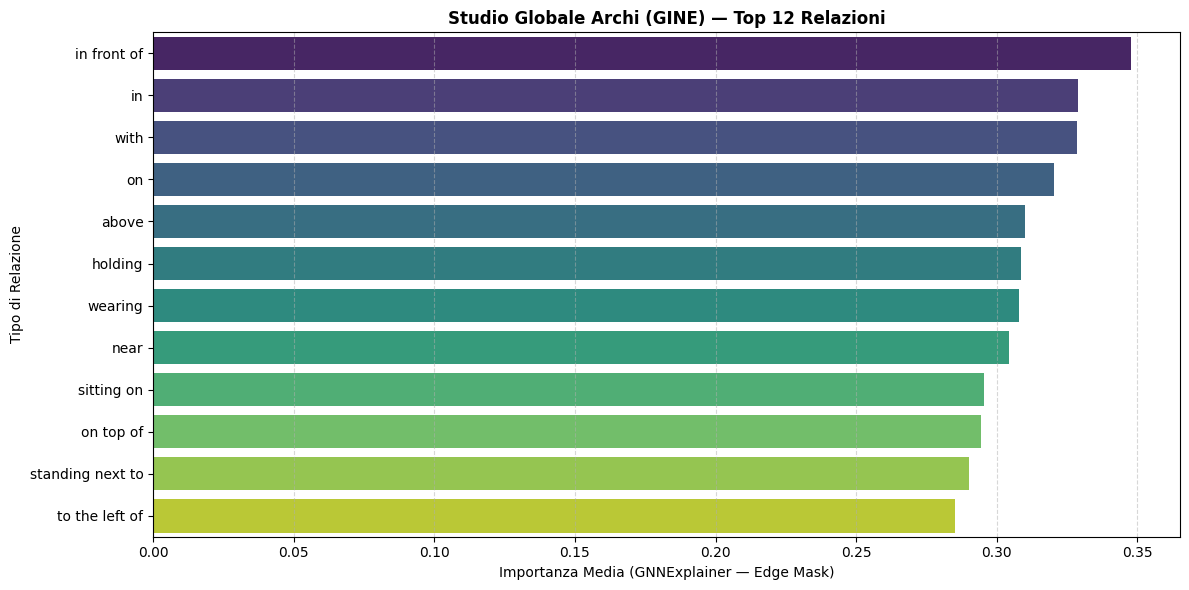

In [22]:
df_edges_gine = analyze_global_edge_importance_with_explainer(
    dataset_gine=val_dataset_gine,
    model_gine=gine_model,
    rel_vocab_gine=rel_vocab_gine,
    device=device,
    num_samples=100,
)

# 1. Filtra il DataFrame di GINE escludendo relazioni con meno di 5 apparizioni
df_edges_gine_clean = df_edges_gine[df_edges_gine['Conteggio'] >= 5]

# 2. Mostra le prime 12 o 15 relazioni rimaste (saranno tutte stabilissime!)
print(df_edges_gine_clean.head(12))

# 3. Disegna il grafico finale pulito solo per GINE
plot_global_edge_study(df_edges_gine_clean, topk=12, model_name="GINE")

## 3 · Studio Globale Archi — GCN (GNNExplainer)

Analisi archi (GCN — GNNExplainer) su 100 campioni...


p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


                    Relazione  Importanza Media  Conteggio
0                door → shirt          0.555357          6
1     toothbrush → toothbrush          0.507330          8
2         elephant → elephant          0.485184         20
3               books → books          0.478632          8
4                  cat → tail          0.471531          5
5            windows → window          0.471311          6
6               head → person          0.471042          5
7                 hat → woman          0.468476          8
8                trees → roof          0.455241          5
9            airplane → wings          0.439309          5
10              cliff → cliff          0.432547          8
11  toilet bowl → toilet bowl          0.417271         12
12                 man → coat          0.408580         14
13               wall → shelf          0.407742          8
14        airplane → airplane          0.405610         12


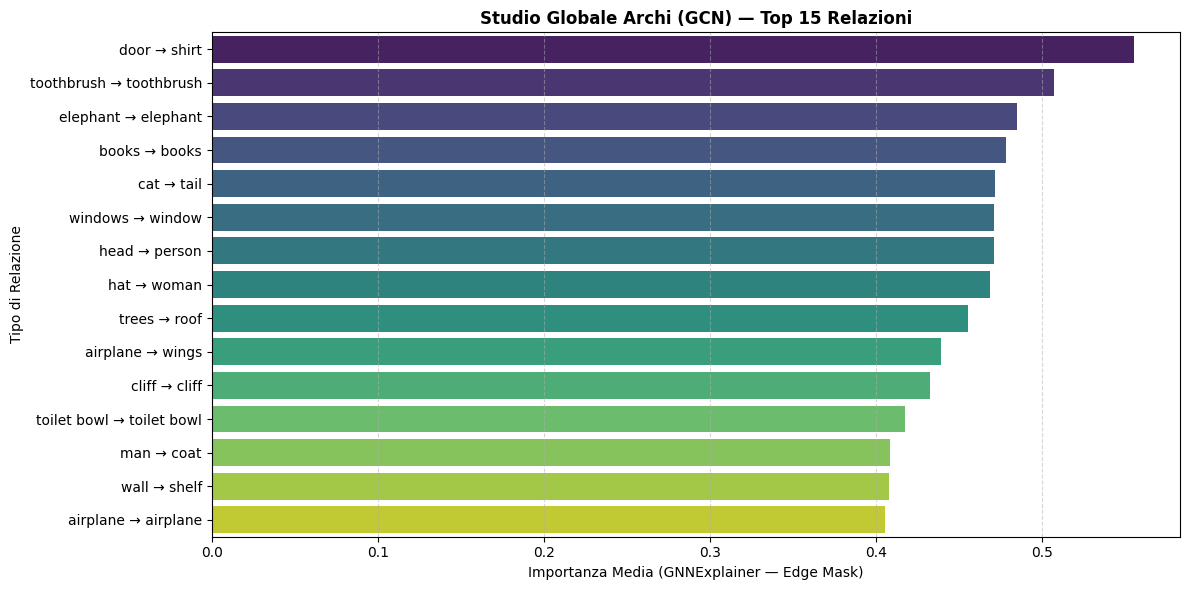

In [23]:
# Nel tuo Notebook, modifica la cella del punto 3 così:
df_edges_gcn = analyze_global_edge_importance_gcn(
    dataset_gcn=val_dataset_gcn,
    model_gcn=gcn_model,
    node_vocab_gcn=node_vocab_gcn,
    device=device,
    num_samples=100,  
    min_count=5       # <--- Filtra le relazioni che appaiono meno di 5 volte su 50 grafi
)

df_edges_gcn = df_edges_gcn[df_edges_gcn['Conteggio'] >= 5]
print(df_edges_gcn.head(15))
plot_global_edge_study(df_edges_gcn, topk=15, model_name="GCN")

## 4 · Focal Point Analysis — Impatto Causale sul Ranking

Le sezioni precedenti misurano correlazioni tra struttura del grafo e output.
La **Focal Point Analysis** risponde alla domanda causale:

> *"Se questa relazione non esistesse, il ranking dei vicini cambierebbe?"*

Ogni tipo di relazione viene rimosso dall'input e si misura la disruption
del top-k ranking nello spazio metrico.

**Step 1** — costruiamo la gallery degli embedding sul validation set.

**FIX rispetto alla versione precedente**: `build_gallery_embeddings` accetta
ora `model_type` per usare la firma corretta di GCN (`no num_graphs`) e GINE.

In [24]:
print("Building GCN gallery embeddings...")
gallery_embs_gcn  = build_gallery_embeddings(
    gcn_model, val_dataset_gcn, device, model_type="gcn"
)
print("Building GINE gallery embeddings...")
gallery_embs_gine = build_gallery_embeddings(
    gine_model, val_dataset_gine, device, model_type="gine"
)
print(f"Gallery GCN:  {gallery_embs_gcn.shape}")
print(f"Gallery GINE: {gallery_embs_gine.shape}")

Building GCN gallery embeddings...
Building GINE gallery embeddings...
Gallery GCN:  torch.Size([3208, 128])
Gallery GINE: torch.Size([3208, 128])


### 4a · Robustness by Relation Type — Delta Embedding

Prima misura: quanto si sposta l'embedding (norma L2) quando si rimuove
ogni tipo di relazione. Un delta alto = relazione strutturalmente critica.

In [25]:
from src.utils.GraphGradCAM import robustness_by_relation_type_gcn, focal_point_analysis_gcn

NUM_SAMPLES = 100

In [26]:
print("Calcolo spostamento degli embedding (Delta L2) su GCN...")
robustness_gcn_series = robustness_by_relation_type_gcn(
    model=gcn_model,
    dataset=val_dataset_gcn,
    node_vocab=node_vocab_gcn,
    device=device,
    num_samples=NUM_SAMPLES  # Coerente con i campioni estratti per il ranking
)

# Conversione in DataFrame per l'ispezione numerica
df_robustness_gcn = robustness_gcn_series.reset_index()
df_robustness_gcn.columns = ['Relazione', 'Importanza Media']

print("\n[Top Spostamenti dell'Embedding (Delta L2) - GCN]")
print(df_robustness_gcn.head(10))

Calcolo spostamento degli embedding (Delta L2) su GCN...

[Top Spostamenti dell'Embedding (Delta L2) - GCN]
               Relazione  Importanza Media
0         airplane → fan          0.850188
1        ottoman → chair          0.444688
2           wall → tiles          0.436006
3  sailboat → lighthouse          0.399398
4  lighthouse → sailboat          0.377882
5            chair → cat          0.376163
6           wall → spice          0.362878
7       chair → branches          0.358571
8          boat → harbor          0.349149
9         bench → bushes          0.344326


In [27]:
print("Robustness GINE...")
rob_gine = robustness_by_relation_type(
    gine_model, val_dataset_gine, rel_vocab_gine, device,
    num_samples=NUM_SAMPLES, model_type="gine"
)


Robustness GINE...


In [28]:
print("\nTop-10 relazioni critiche (delta embedding) — GINE:")
print(rob_gine.head(10).to_string())


Top-10 relazioni critiche (delta embedding) — GINE:
to the left of     0.102164
to the right of    0.090513
on                 0.051016
in                 0.023119
wearing            0.020347
of                 0.012233
near               0.010031
in front of        0.006184
on top of          0.005762
lying on           0.004492


### 4b · Focal Point Analysis — Ranking Disruption

Misura più rilevante per retrieval: quanto cambia il top-k ranking
quando si rimuove ogni tipo di relazione.

`Disruption = 1 − overlap(top-k base, top-k perturbed)`

In [29]:
TOPK = 10

print("Focal Point Analysis — GINE...")
focal_gine = focal_point_analysis(
    gine_model, val_dataset_gine, gallery_embs_gine, rel_vocab_gine,
    device=device, topk=TOPK, num_samples=NUM_SAMPLES, model_type="gine"
)

print("\nTop-10 focal point relazioni — GINE:")
print(focal_gine.head(10).to_string())

Focal Point Analysis — GINE...

Top-10 focal point relazioni — GINE:
to the left of     0.542857
to the right of    0.485714
on                 0.245918
wearing            0.128571
in                 0.121429
near               0.069388
of                 0.063918
on top of          0.044898
in front of        0.036735
holding            0.029592


In [30]:
print("Esecuzione Focal Point Analysis su GCN...")
focal_gcn_series = focal_point_analysis_gcn(
    model=gcn_model,
    dataset=val_dataset_gcn,
    gallery_embs=gallery_embs_gcn,
    node_vocab=node_vocab_gcn,
    device=device,
    topk=10,
    num_samples=NUM_SAMPLES # Puoi aumentare questo valore per una stima più robusta
)


Esecuzione Focal Point Analysis su GCN...


In [31]:
# 3. Visualizzazione dei risultati tramite DataFrame e Plot
df_focal_gcn = focal_gcn_series.reset_index()
df_focal_gcn.columns = ['Relazione', 'Importanza Media']

print("\nTop 10 Focal Points Critici (GCN):")
print(df_focal_gcn.head(15))


Top 10 Focal Points Critici (GCN):
          Relazione  Importanza Media
0     leaves → tree          0.516667
1    person → shirt          0.400000
2      sky → clouds          0.366667
3    shirt → person          0.320000
4      clouds → sky          0.300000
5        coat → man          0.260000
6     tree → leaves          0.233333
7      man → shorts          0.200000
8      person → man          0.200000
9      hand → shirt          0.183333
10  person → person          0.180000
11    woman → shirt          0.171429
12       man → coat          0.160000
13      woman → man          0.150000
14      man → shirt          0.150000
